In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [17]:
df = pd.read_csv("Salary Data.csv")

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [18]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
None
              Age  Years of Experience         Salary
count  373.000000           373.000000     373.000000
mean    37.431635            10.030831  100577.345845
std      7.069073             6.557007   48240.013482
min     23.000000             0.000000     350.000000
25%     31.000000             4.000000   55000.000000
50%     36.000000             9.000000   95000.000000
75%     44.000000            15.000000  140000.000000
max   

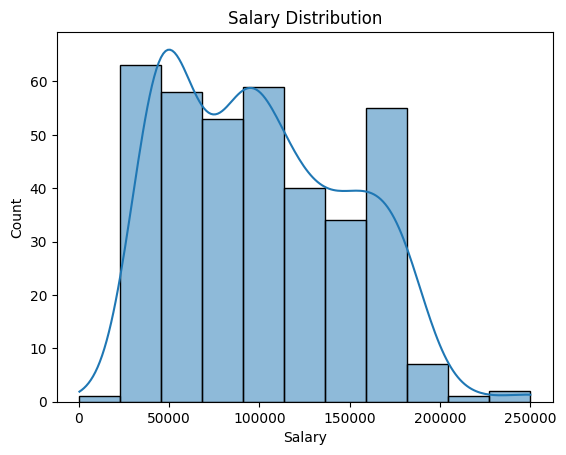

In [19]:
sns.histplot(df["Salary"], kde=True)

plt.title("Salary Distribution")

plt.show()

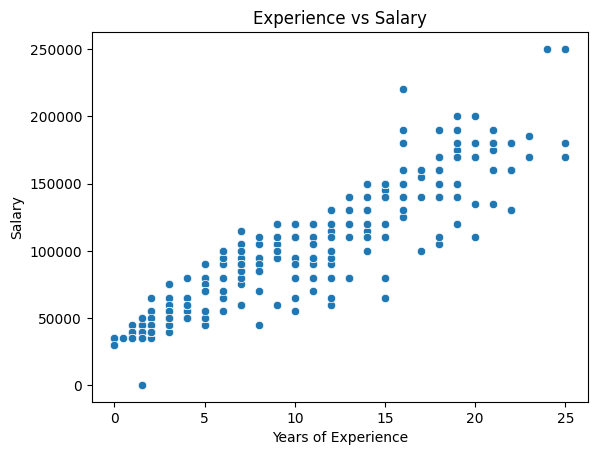

In [20]:
sns.scatterplot(x="Years of Experience", y="Salary", data=df)

plt.title("Experience vs Salary")

plt.show()

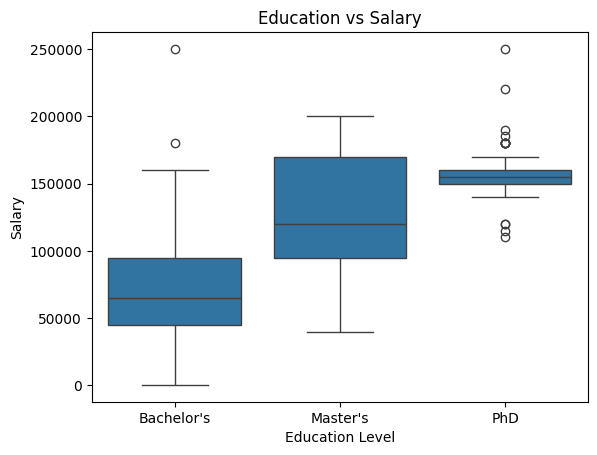

In [21]:
sns.boxplot(x="Education Level", y="Salary", data=df)

plt.title("Education vs Salary")

plt.show()

In [22]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,Age,Years of Experience,Salary,Gender_Male,Education Level_Master's,Education Level_PhD,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Business Analyst,Job Title_Business Development Manager,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,32.0,5.0,90000.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,28.0,3.0,65000.0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,45.0,15.0,150000.0,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,36.0,7.0,60000.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,52.0,20.0,200000.0,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [32]:
df_encoded=df_encoded.dropna()
X = df_encoded.drop("Salary", axis=1)

y = df_encoded["Salary"]
print(y.shape)

(373,)


In [31]:


X_vif = X.astype(float)

vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

print(vif_data)

                        Feature         VIF
0                           Age  532.662906
1           Years of Experience  121.791776
2                   Gender_Male    5.218861
3      Education Level_Master's    7.024960
4           Education Level_PhD    9.295074
..                          ...         ...
173       Job Title_UX Designer    1.934935
174     Job Title_UX Researcher    1.744675
175     Job Title_VP of Finance    1.971827
176  Job Title_VP of Operations    1.971827
177     Job Title_Web Developer    1.698534

[178 rows x 2 columns]


In [33]:
X = X.drop("Age", axis=1)

In [34]:
X = X.drop("Years of Experience", axis=1)

In [35]:

X.shape

(373, 176)

In [36]:
X_vif = X.astype(float)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

print(vif_data)

                                Feature       VIF
0                           Gender_Male  5.170590
1              Education Level_Master's  6.558270
2                   Education Level_PhD  8.497741
3                  Job Title_Accountant  1.000000
4    Job Title_Administrative Assistant  1.000000
..                                  ...       ...
171               Job Title_UX Designer  1.066921
172             Job Title_UX Researcher  1.066921
173             Job Title_VP of Finance  1.097589
174          Job Title_VP of Operations  1.097589
175             Job Title_Web Developer  1.026653

[176 rows x 2 columns]


In [37]:
X = X.drop("Education Level_Master's", axis=1)
X=X.drop("Education Level_PhD",axis=1)
y.shape

(373,)

In [38]:

X=X.astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [39]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [40]:
y_pred = model.predict(X_test)

In [41]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 23874.24554747378


In [42]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 1249634379.9836018


In [43]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 35350.16803331494


In [44]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.4787939414960434


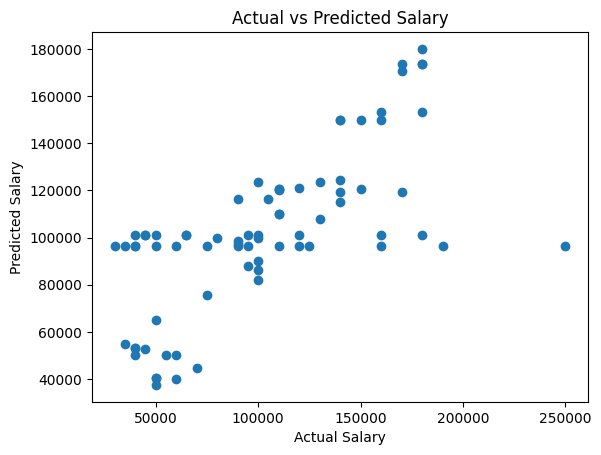

In [45]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()